<a href="https://colab.research.google.com/github/yana-g/graph-analysis/blob/main/04_Centrality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 4: Centrality Analysis

This notebook identifies the most important actors in the Israeli film collaboration network using four centrality measures:

- **Degree Centrality** — actors with the largest number of direct collaborators
- **Betweenness Centrality** — actors who connect different parts of the network
- **Closeness Centrality** — actors who are structurally close to the rest of the network
- **Eigenvector Centrality** — actors connected to other influential actors

The notebook also compares rankings, examines correlations between the measures, links actors to their communities when available, and exports the results.


### 1. Imports


In [1]:
from pathlib import Path
import pickle
import time

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)


### 2. Load the Collaboration Graph

The notebook first tries to load the graph created in Stage 1.  
If the pickle file is unavailable, it rebuilds the graph from `actor_edges.csv`.


In [2]:
GRAPH_FILE = Path("israeli_actors_graph.pkl")
EDGES_FILE = Path("actor_edges.csv")
COMMUNITIES_FILE = Path("actor_communities.csv")

if GRAPH_FILE.exists():
    with GRAPH_FILE.open("rb") as file:
        G = pickle.load(file)

    graph_source = str(GRAPH_FILE)

elif EDGES_FILE.exists():
    edges_df = pd.read_csv(
        EDGES_FILE,
        encoding="utf-8-sig"
    )

    required_columns = {
        "actor_1",
        "actor_2",
        "movie_title",
        "year"
    }

    missing_columns = required_columns.difference(
        edges_df.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing columns in actor_edges.csv: "
            f"{sorted(missing_columns)}"
        )

    G = nx.Graph()

    for row in edges_df.itertuples(index=False):
        actor_1 = str(row.actor_1).strip()
        actor_2 = str(row.actor_2).strip()

        if (
            not actor_1
            or not actor_2
            or actor_1 == "nan"
            or actor_2 == "nan"
            or actor_1 == actor_2
        ):
            continue

        if G.has_edge(actor_1, actor_2):
            G[actor_1][actor_2]["weight"] += 1
        else:
            G.add_edge(
                actor_1,
                actor_2,
                weight=1
            )

    graph_source = str(EDGES_FILE)

else:
    raise FileNotFoundError(
        "Neither israeli_actors_graph.pkl nor "
        "actor_edges.csv was found."
    )

print("Graph source:", graph_source)
print("Actors (nodes):", G.number_of_nodes())
print("Collaborations (edges):", G.number_of_edges())
print(
    "Connected components:",
    nx.number_connected_components(G)
)
print(
    "Isolated actors:",
    nx.number_of_isolates(G)
)


Graph source: actor_edges.csv
Actors (nodes): 3188
Collaborations (edges): 27896
Connected components: 45
Isolated actors: 0


### 3. Validate and Prepare the Graph

For shortest-path centralities, collaboration strength is converted into distance:

\[
distance(u,v)=\frac{1}{weight(u,v)}
\]

A pair that appeared together in more films is therefore considered structurally closer.


In [3]:
if G.is_directed():
    raise ValueError(
        "The collaboration graph must be undirected."
    )

if nx.number_of_selfloops(G) > 0:
    G.remove_edges_from(
        nx.selfloop_edges(G)
    )

for actor_1, actor_2, data in G.edges(data=True):
    weight = data.get("weight", 1)

    try:
        weight = float(weight)
    except (TypeError, ValueError):
        weight = 1.0

    if weight <= 0:
        weight = 1.0

    data["weight"] = weight
    data["distance"] = 1.0 / weight

components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

largest_component_nodes = components[0]

G_lcc = G.subgraph(
    largest_component_nodes
).copy()

print(
    "Largest connected component:",
    G_lcc.number_of_nodes(),
    "actors and",
    G_lcc.number_of_edges(),
    "edges"
)

print(
    "Largest component share:",
    f"{G_lcc.number_of_nodes() / G.number_of_nodes():.2%}"
)


Largest connected component: 2996 actors and 27447 edges
Largest component share: 93.98%


### 4. Compute Centrality Measures

- Degree centrality is calculated on the full graph.
- Betweenness centrality uses inverse collaboration strength as edge distance.
- Closeness centrality is calculated on the full graph using NetworkX's disconnected-graph correction.
- Eigenvector centrality is calculated on the largest connected component because disconnected components may otherwise receive incomparable scores.


In [4]:
start_time = time.perf_counter()

degree_centrality = nx.degree_centrality(G)

print(
    "Degree centrality completed in",
    round(time.perf_counter() - start_time, 2),
    "seconds"
)


Degree centrality completed in 0.0 seconds


In [5]:
start_time = time.perf_counter()

betweenness_centrality = nx.betweenness_centrality(
    G,
    normalized=True,
    weight="distance"
)

print(
    "Betweenness centrality completed in",
    round(time.perf_counter() - start_time, 2),
    "seconds"
)


Betweenness centrality completed in 198.01 seconds


In [6]:
start_time = time.perf_counter()

closeness_centrality = nx.closeness_centrality(
    G,
    distance="distance",
    wf_improved=True
)

print(
    "Closeness centrality completed in",
    round(time.perf_counter() - start_time, 2),
    "seconds"
)


Closeness centrality completed in 108.02 seconds


In [7]:
start_time = time.perf_counter()

try:
    eigenvector_lcc = nx.eigenvector_centrality(
        G_lcc,
        max_iter=3000,
        tol=1e-08,
        weight="weight"
    )
except nx.PowerIterationFailedConvergence:
    eigenvector_lcc = nx.eigenvector_centrality_numpy(
        G_lcc,
        weight="weight"
    )

eigenvector_centrality = {
    actor: eigenvector_lcc.get(actor, 0.0)
    for actor in G.nodes()
}

print(
    "Eigenvector centrality completed in",
    round(time.perf_counter() - start_time, 2),
    "seconds"
)


Eigenvector centrality completed in 1.5 seconds


### 5. Build the Centrality Results Table


In [8]:
weighted_degree = dict(
    G.degree(weight="weight")
)

centrality_df = pd.DataFrame({
    "Actor": list(G.nodes()),
    "Degree": [
        G.degree(actor)
        for actor in G.nodes()
    ],
    "Weighted Degree": [
        weighted_degree.get(actor, 0.0)
        for actor in G.nodes()
    ],
    "Degree Centrality": [
        degree_centrality.get(actor, 0.0)
        for actor in G.nodes()
    ],
    "Betweenness Centrality": [
        betweenness_centrality.get(actor, 0.0)
        for actor in G.nodes()
    ],
    "Closeness Centrality": [
        closeness_centrality.get(actor, 0.0)
        for actor in G.nodes()
    ],
    "Eigenvector Centrality": [
        eigenvector_centrality.get(actor, 0.0)
        for actor in G.nodes()
    ]
})

if COMMUNITIES_FILE.exists():
    communities_df = pd.read_csv(
        COMMUNITIES_FILE,
        encoding="utf-8-sig"
    )

    communities_df.columns = [
        column.strip().lower()
        for column in communities_df.columns
    ]

    if {"actor", "community"}.issubset(
        communities_df.columns
    ):
        communities_df = (
            communities_df[
                ["actor", "community"]
            ]
            .rename(columns={
                "actor": "Actor",
                "community": "Community"
            })
            .drop_duplicates(subset="Actor")
        )

        centrality_df = centrality_df.merge(
            communities_df,
            on="Actor",
            how="left"
        )

centrality_df.head()


,Actor,Degree,Weighted Degree,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
0,בתיה לנצט,15,15.0,0.004707,0.000007,0.360542,0.009128
1,חיים טופול,35,44.0,0.010982,0.000183,0.479718,0.051513
2,אילנה רובינא,8,8.0,0.002510,0.000000,0.359037,0.008175
3,גדעון זינגר,128,201.0,0.040163,0.036779,0.552998,0.212281
4,זאב ברלינסקי,43,44.0,0.013492,0.000156,0.386713,0.028020


### 6. Rank Actors by Each Measure

Rank 1 represents the highest centrality score.


In [9]:
centrality_columns = [
    "Degree Centrality",
    "Betweenness Centrality",
    "Closeness Centrality",
    "Eigenvector Centrality"
]

for column in centrality_columns:
    rank_column = column.replace(
        " Centrality",
        " Rank"
    )

    centrality_df[rank_column] = (
        centrality_df[column]
        .rank(
            method="min",
            ascending=False
        )
        .astype(int)
    )

centrality_df["Average Rank"] = (
    centrality_df[
        [
            "Degree Rank",
            "Betweenness Rank",
            "Closeness Rank",
            "Eigenvector Rank"
        ]
    ]
    .mean(axis=1)
)

centrality_df = centrality_df.sort_values(
    "Average Rank"
).reset_index(drop=True)

centrality_df.head(20)


,Actor,Degree,Weighted Degree,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality,Degree Rank,Betweenness Rank,Closeness Rank,Eigenvector Rank,Average Rank
0,יוסף שילוח,180,259.0,0.056479,0.081186,0.565516,0.229952,6,1,1,1,2.25
1,זאב רווח,190,266.0,0.059617,0.068777,0.559241,0.200829,5,2,3,5,3.75
2,גבי עמרני,177,244.0,0.055538,0.051521,0.561919,0.211244,8,4,2,4,4.50
3,גילה אלמגור,217,276.0,0.068089,0.064370,0.555166,0.184905,2,3,6,7,4.50
4,גדעון זינגר,128,201.0,0.040163,0.036779,0.552998,0.212281,21,12,7,3,10.75
5,שייקה אופיר,124,200.0,0.038908,0.035464,0.558572,0.225027,24,14,5,2,11.25
6,משה איבגי,206,239.0,0.064638,0.047698,0.541777,0.091374,3,6,8,29,11.50
7,לבנה פינקלשטיין,159,186.0,0.049890,0.040274,0.537215,0.102062,11,8,10,20,12.25
8,אבנר חזקיהו,112,172.0,0.035143,0.039964,0.558627,0.192339,32,9,4,6,12.75
9,אריה מוסקונה,157,188.0,0.049263,0.032720,0.540680,0.116341,12,16,9,14,12.75


### 7. Degree Centrality


In [10]:
TOP_N = 20

top_degree_df = (
    centrality_df
    .sort_values(
        [
            "Degree Centrality",
            "Weighted Degree"
        ],
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

display(
    top_degree_df[
        [
            column
            for column in [
                "Actor",
                "Community",
                "Degree",
                "Weighted Degree",
                "Degree Centrality"
            ]
            if column in top_degree_df.columns
        ]
    ].style.format({
        "Degree Centrality": "{:.4f}"
    })
)


,Actor,Degree,Weighted Degree,Degree Centrality
10,אלון אבוטבול,225,252.000000,0.0706
3,גילה אלמגור,217,276.000000,0.0681
6,משה איבגי,206,239.000000,0.0646
13,אסי דיין,202,235.000000,0.0634
1,זאב רווח,190,266.000000,0.0596
0,יוסף שילוח,180,259.000000,0.0565
12,עמוס לביא,178,205.000000,0.0559
2,גבי עמרני,177,244.000000,0.0555
16,אורי גבריאל,166,192.000000,0.0521
31,צחי גראד,160,178.000000,0.0502


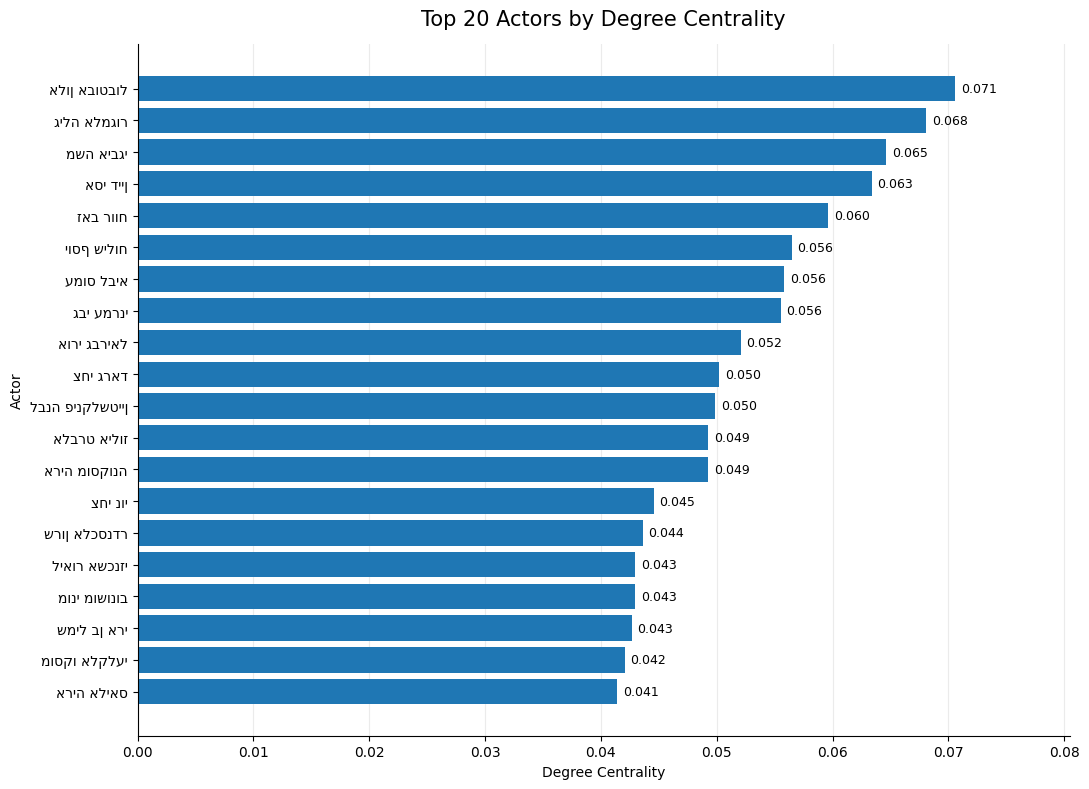

In [11]:
plot_df = top_degree_df.sort_values(
    "Degree Centrality",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_df["Actor"],
    plot_df["Degree Centrality"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in plot_df["Degree Centrality"]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 20 Actors by Degree Centrality",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Degree Centrality")
ax.set_ylabel("Actor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim(
    0,
    plot_df["Degree Centrality"].max() * 1.14
)

plt.tight_layout()
plt.show()


### 8. Betweenness Centrality


In [12]:
top_betweenness_df = (
    centrality_df
    .sort_values(
        "Betweenness Centrality",
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

display(
    top_betweenness_df[
        [
            column
            for column in [
                "Actor",
                "Community",
                "Degree",
                "Betweenness Centrality"
            ]
            if column in top_betweenness_df.columns
        ]
    ].style.format({
        "Betweenness Centrality": "{:.5f}"
    })
)


,Actor,Degree,Betweenness Centrality
0,יוסף שילוח,180,0.08119
1,זאב רווח,190,0.06878
3,גילה אלמגור,217,0.06437
2,גבי עמרני,177,0.05152
12,עמוס לביא,178,0.05049
6,משה איבגי,206,0.04770
10,אלון אבוטבול,225,0.04440
7,לבנה פינקלשטיין,159,0.04027
8,אבנר חזקיהו,112,0.03996
13,אסי דיין,202,0.03793


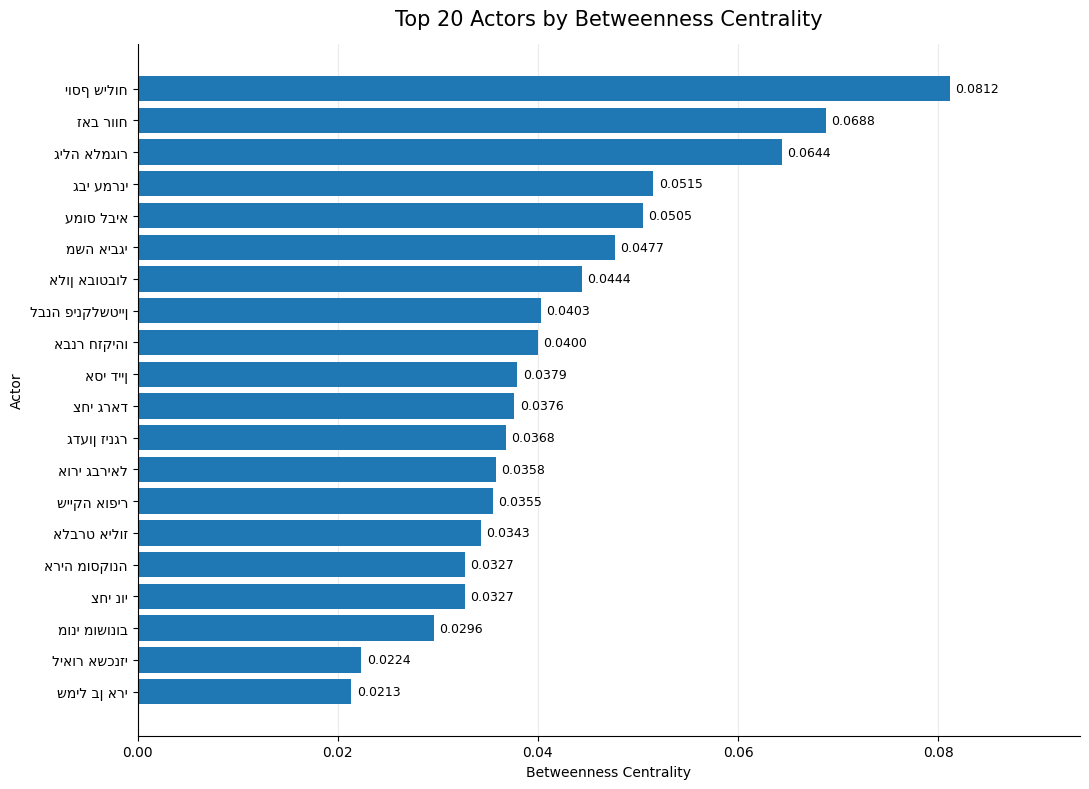

In [13]:
plot_df = top_betweenness_df.sort_values(
    "Betweenness Centrality",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_df["Actor"],
    plot_df["Betweenness Centrality"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in plot_df["Betweenness Centrality"]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 20 Actors by Betweenness Centrality",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Betweenness Centrality")
ax.set_ylabel("Actor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim(
    0,
    plot_df["Betweenness Centrality"].max() * 1.16
)

plt.tight_layout()
plt.show()


### 9. Closeness Centrality


In [14]:
top_closeness_df = (
    centrality_df
    .sort_values(
        "Closeness Centrality",
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

display(
    top_closeness_df[
        [
            column
            for column in [
                "Actor",
                "Community",
                "Degree",
                "Closeness Centrality"
            ]
            if column in top_closeness_df.columns
        ]
    ].style.format({
        "Closeness Centrality": "{:.4f}"
    })
)


,Actor,Degree,Closeness Centrality
0,יוסף שילוח,180,0.5655
2,גבי עמרני,177,0.5619
1,זאב רווח,190,0.5592
8,אבנר חזקיהו,112,0.5586
5,שייקה אופיר,124,0.5586
3,גילה אלמגור,217,0.5552
4,גדעון זינגר,128,0.5530
6,משה איבגי,206,0.5418
9,אריה מוסקונה,157,0.5407
7,לבנה פינקלשטיין,159,0.5372


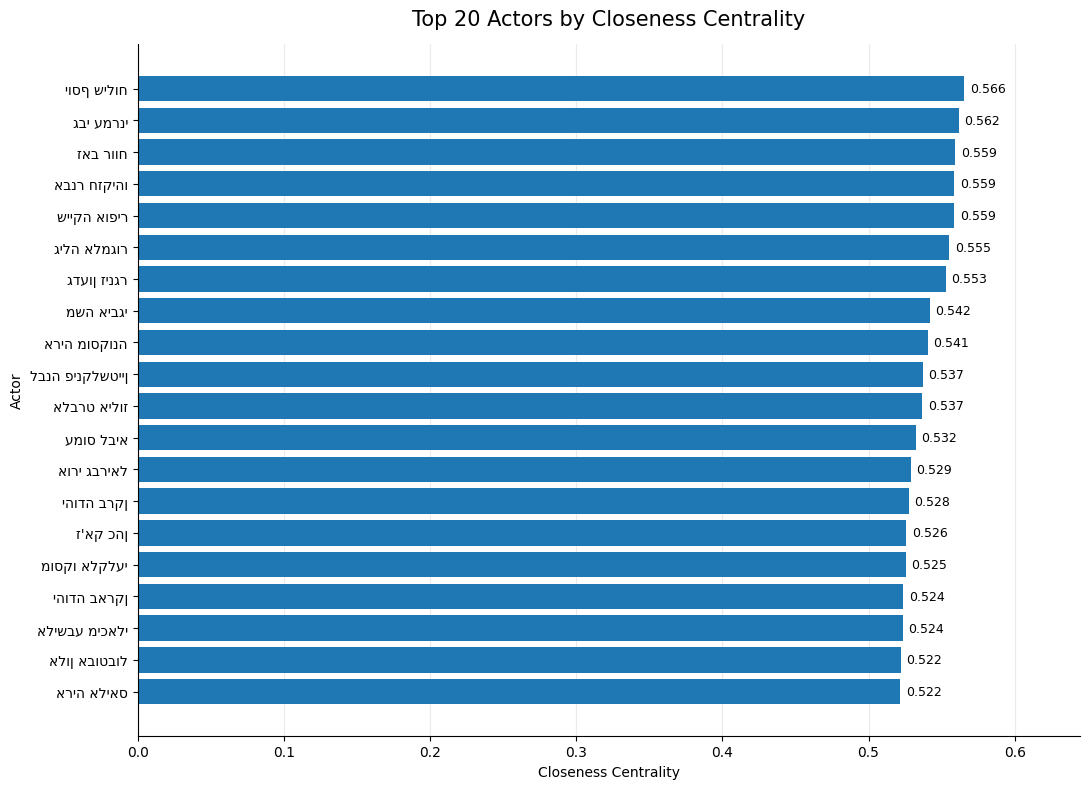

In [15]:
plot_df = top_closeness_df.sort_values(
    "Closeness Centrality",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_df["Actor"],
    plot_df["Closeness Centrality"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in plot_df["Closeness Centrality"]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 20 Actors by Closeness Centrality",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Closeness Centrality")
ax.set_ylabel("Actor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim(
    0,
    plot_df["Closeness Centrality"].max() * 1.14
)

plt.tight_layout()
plt.show()


### 10. Eigenvector Centrality


In [16]:
top_eigenvector_df = (
    centrality_df
    .sort_values(
        "Eigenvector Centrality",
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

display(
    top_eigenvector_df[
        [
            column
            for column in [
                "Actor",
                "Community",
                "Degree",
                "Weighted Degree",
                "Eigenvector Centrality"
            ]
            if column in top_eigenvector_df.columns
        ]
    ].style.format({
        "Eigenvector Centrality": "{:.5f}"
    })
)


,Actor,Degree,Weighted Degree,Eigenvector Centrality
0,יוסף שילוח,180,259.000000,0.22995
5,שייקה אופיר,124,200.000000,0.22503
4,גדעון זינגר,128,201.000000,0.21228
2,גבי עמרני,177,244.000000,0.21124
1,זאב רווח,190,266.000000,0.20083
8,אבנר חזקיהו,112,172.000000,0.19234
3,גילה אלמגור,217,276.000000,0.18490
15,מוסקו אלקלעי,134,165.000000,0.13352
62,בומבה צור,74,107.000000,0.12360
14,אלישבע מיכאלי,126,154.000000,0.12176


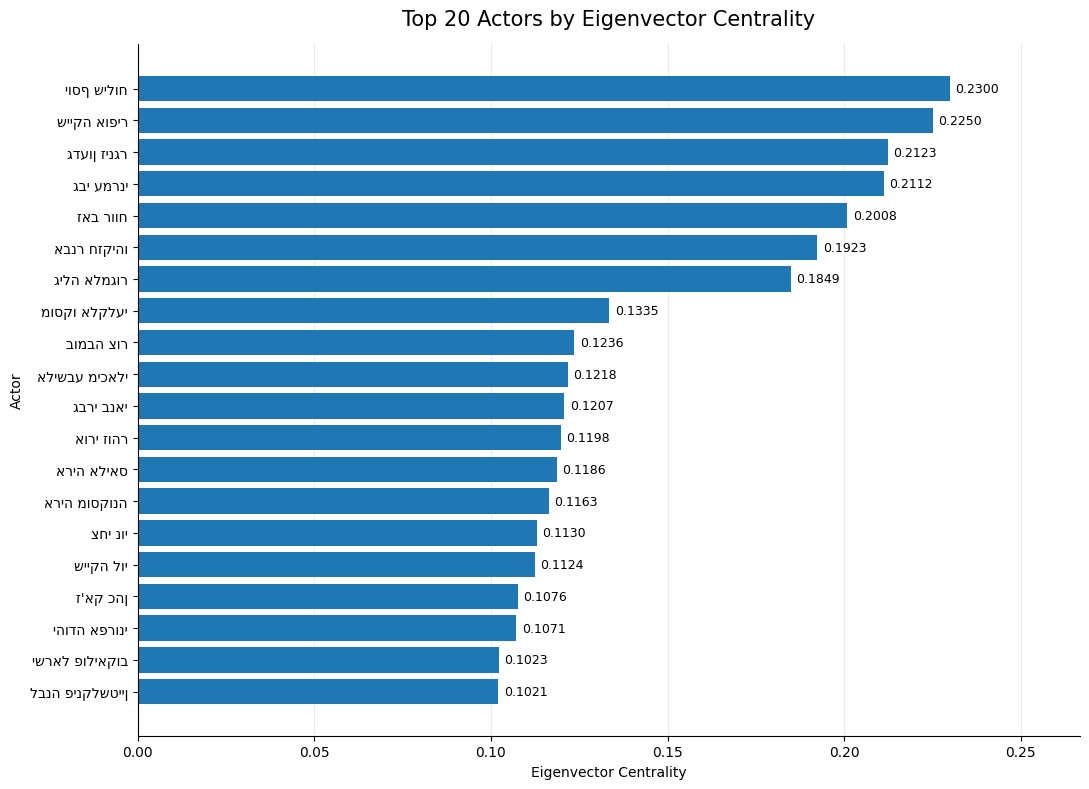

In [17]:
plot_df = top_eigenvector_df.sort_values(
    "Eigenvector Centrality",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_df["Actor"],
    plot_df["Eigenvector Centrality"]
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.4f}"
        for value in plot_df["Eigenvector Centrality"]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 20 Actors by Eigenvector Centrality",
    fontsize=15,
    pad=14
)
ax.set_xlabel("Eigenvector Centrality")
ax.set_ylabel("Actor")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim(
    0,
    plot_df["Eigenvector Centrality"].max() * 1.16
)

plt.tight_layout()
plt.show()


### 11. Compare the Rankings

The table below highlights actors who consistently rank highly across several centrality measures.


In [18]:
ranking_columns = [
    "Actor",
    "Degree Rank",
    "Betweenness Rank",
    "Closeness Rank",
    "Eigenvector Rank",
    "Average Rank"
]

if "Community" in centrality_df.columns:
    ranking_columns.insert(
        1,
        "Community"
    )

ranking_comparison_df = (
    centrality_df[ranking_columns]
    .sort_values("Average Rank")
    .head(30)
)

display(
    ranking_comparison_df.style.format({
        "Average Rank": "{:.1f}"
    })
)


,Actor,Degree Rank,Betweenness Rank,Closeness Rank,Eigenvector Rank,Average Rank
0,יוסף שילוח,6,1,1,1,2.2
1,זאב רווח,5,2,3,5,3.8
2,גבי עמרני,8,4,2,4,4.5
3,גילה אלמגור,2,3,6,7,4.5
4,גדעון זינגר,21,12,7,3,10.8
5,שייקה אופיר,24,14,5,2,11.2
6,משה איבגי,3,6,8,29,11.5
7,לבנה פינקלשטיין,11,8,10,20,12.2
8,אבנר חזקיהו,32,9,4,6,12.8
9,אריה מוסקונה,12,16,9,14,12.8


### 12. Overlap Between the Top Rankings

A high overlap means that different centrality measures identify similar actors.  
A low overlap means that each measure captures a different structural role.


In [19]:
top_sets = {
    "Degree": set(
        top_degree_df["Actor"]
    ),
    "Betweenness": set(
        top_betweenness_df["Actor"]
    ),
    "Closeness": set(
        top_closeness_df["Actor"]
    ),
    "Eigenvector": set(
        top_eigenvector_df["Actor"]
    )
}

overlap_rows = []

measure_names = list(top_sets)

for index, measure_1 in enumerate(measure_names):
    for measure_2 in measure_names[index + 1:]:
        intersection = (
            top_sets[measure_1]
            & top_sets[measure_2]
        )

        overlap_rows.append({
            "Measure 1": measure_1,
            "Measure 2": measure_2,
            "Shared Top-20 Actors": len(intersection),
            "Overlap (%)": round(
                len(intersection) / TOP_N * 100,
                1
            )
        })

overlap_df = pd.DataFrame(overlap_rows)

overlap_df


,Measure 1,Measure 2,Shared Top-20 Actors,Overlap (%)
0,Degree,Betweenness,17,85.0
1,Degree,Closeness,13,65.0
2,Degree,Eigenvector,9,45.0
3,Betweenness,Closeness,14,70.0
4,Betweenness,Eigenvector,10,50.0
5,Closeness,Eigenvector,13,65.0


### 13. Correlation Between Centrality Measures


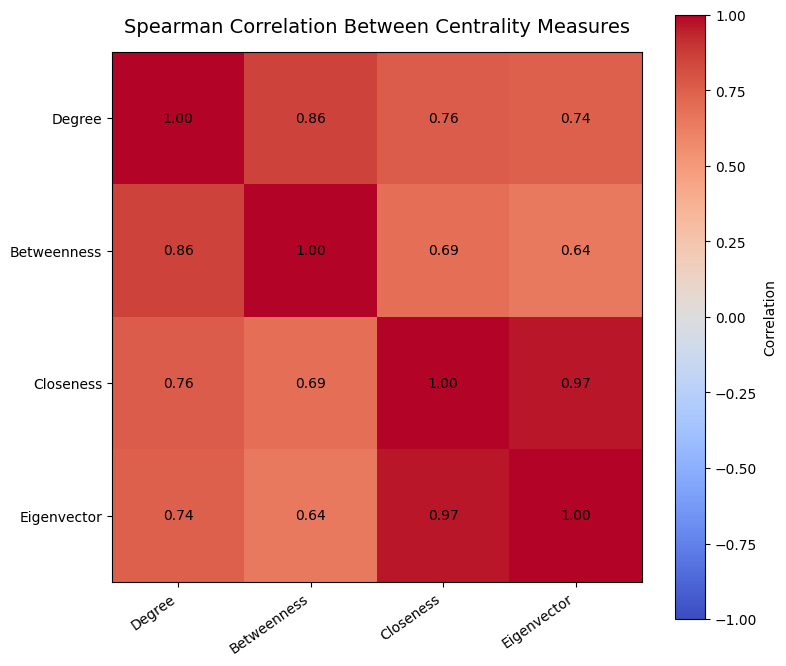

,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
Degree Centrality,1.000000,0.859302,0.761492,0.743098
Betweenness Centrality,0.859302,1.000000,0.693848,0.642052
Closeness Centrality,0.761492,0.693848,1.000000,0.965470
Eigenvector Centrality,0.743098,0.642052,0.965470,1.000000


In [20]:
centrality_correlation = (
    centrality_df[centrality_columns]
    .corr(method="spearman")
)

fig, ax = plt.subplots(figsize=(8, 7))

image = ax.imshow(
    centrality_correlation,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(
    range(len(centrality_columns))
)
ax.set_yticks(
    range(len(centrality_columns))
)

short_labels = [
    "Degree",
    "Betweenness",
    "Closeness",
    "Eigenvector"
]

ax.set_xticklabels(
    short_labels,
    rotation=35,
    ha="right"
)
ax.set_yticklabels(short_labels)

for row_index in range(
    len(centrality_columns)
):
    for column_index in range(
        len(centrality_columns)
    ):
        ax.text(
            column_index,
            row_index,
            f"{centrality_correlation.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title(
    "Spearman Correlation Between Centrality Measures",
    fontsize=14,
    pad=14
)

fig.colorbar(
    image,
    ax=ax,
    label="Correlation"
)

plt.tight_layout()
plt.show()

centrality_correlation


### 14. Actors with Distinct Structural Roles

The following tables identify actors whose role is especially strong in one measure relative to their other rankings.


In [21]:
distinct_roles_df = centrality_df.copy()

distinct_roles_df["Bridge Advantage"] = (
    distinct_roles_df["Degree Rank"]
    - distinct_roles_df["Betweenness Rank"]
)

distinct_roles_df["Star Network Advantage"] = (
    distinct_roles_df["Degree Rank"]
    - distinct_roles_df["Eigenvector Rank"]
)

print("Actors whose betweenness rank is much stronger than degree rank:")

display(
    distinct_roles_df
    .sort_values(
        "Bridge Advantage",
        ascending=False
    )
    .head(15)[
        [
            column
            for column in [
                "Actor",
                "Community",
                "Degree Rank",
                "Betweenness Rank",
                "Bridge Advantage"
            ]
            if column in distinct_roles_df.columns
        ]
    ]
)

print(
    "\nActors whose eigenvector rank is much stronger "
    "than degree rank:"
)

display(
    distinct_roles_df
    .sort_values(
        "Star Network Advantage",
        ascending=False
    )
    .head(15)[
        [
            column
            for column in [
                "Actor",
                "Community",
                "Degree Rank",
                "Eigenvector Rank",
                "Star Network Advantage"
            ]
            if column in distinct_roles_df.columns
        ]
    ]
)


Actors whose betweenness rank is much stronger than degree rank:


,Actor,Degree Rank,Betweenness Rank,Bridge Advantage
3181,מאיר גרנר,3152,1131,2021
3180,מיה גרנר,3152,1131,2021
3179,סמר,3152,1131,2021
3170,ישראל גודוביץ,3152,1131,2021
3177,יהודה פוליקר,3152,1131,2021
3169,נעם קפלן,3152,1131,2021
3168,טובה ורובל,3152,1131,2021
3167,ירון פינק,3152,1131,2021
3166,שירז טל,3152,1131,2021
3165,עידן טוקלומטי-ג'ורנו,3152,1131,2021



Actors whose eigenvector rank is much stronger than degree rank:


,Actor,Degree Rank,Eigenvector Rank,Star Network Advantage
1493,מירי זמיר,2817,683,2134
1261,נעמי גרינבאום,2375,334,2041
1703,דבי הס,2817,820,1997
2060,מיכאל גור,3096,1125,1971
2052,"להקת הנח""ל",2939,997,1942
1426,קרלו דה מאיו,2534,618,1916
1425,דניאל דובלינו,2534,618,1916
1427,קטיה כריסטין,2534,618,1916
1424,פרנקו ג’ורנלי,2534,618,1916
1423,נטע סובול,2534,629,1905


### 15. Conclusions


In [22]:
degree_leader = top_degree_df.iloc[0]
betweenness_leader = top_betweenness_df.iloc[0]
closeness_leader = top_closeness_df.iloc[0]
eigenvector_leader = top_eigenvector_df.iloc[0]

all_top_actors = (
    top_sets["Degree"]
    & top_sets["Betweenness"]
    & top_sets["Closeness"]
    & top_sets["Eigenvector"]
)

print("Centrality Analysis Summary")
print("-" * 30)

print(
    f"Most directly connected actor: "
    f"{degree_leader['Actor']} "
    f"({int(degree_leader['Degree'])} unique collaborators)."
)

print(
    f"Main network bridge: "
    f"{betweenness_leader['Actor']} "
    f"(betweenness = "
    f"{betweenness_leader['Betweenness Centrality']:.5f})."
)

print(
    f"Most structurally central actor: "
    f"{closeness_leader['Actor']} "
    f"(closeness = "
    f"{closeness_leader['Closeness Centrality']:.4f})."
)

print(
    f"Actor most connected to other influential actors: "
    f"{eigenvector_leader['Actor']} "
    f"(eigenvector = "
    f"{eigenvector_leader['Eigenvector Centrality']:.5f})."
)

print(
    "Actors appearing in the top 20 of all four measures:",
    len(all_top_actors)
)

if all_top_actors:
    print(
        "Shared leading actors:",
        ", ".join(
            sorted(all_top_actors)
        )
    )


Centrality Analysis Summary
------------------------------
Most directly connected actor: אלון אבוטבול (225 unique collaborators).
Main network bridge: יוסף שילוח (betweenness = 0.08119).
Most structurally central actor: יוסף שילוח (closeness = 0.5655).
Actor most connected to other influential actors: יוסף שילוח (eigenvector = 0.22995).
Actors appearing in the top 20 of all four measures: 6
Shared leading actors: אריה מוסקונה, גבי עמרני, גילה אלמגור, זאב רווח, יוסף שילוח, לבנה פינקלשטיין


### 16. Export Results


In [23]:
centrality_df.to_csv(
    "actor_centrality_all.csv",
    index=False,
    encoding="utf-8-sig"
)

top_degree_df.to_csv(
    "top_degree_centrality.csv",
    index=False,
    encoding="utf-8-sig"
)

top_betweenness_df.to_csv(
    "top_betweenness_centrality.csv",
    index=False,
    encoding="utf-8-sig"
)

top_closeness_df.to_csv(
    "top_closeness_centrality.csv",
    index=False,
    encoding="utf-8-sig"
)

top_eigenvector_df.to_csv(
    "top_eigenvector_centrality.csv",
    index=False,
    encoding="utf-8-sig"
)

ranking_comparison_df.to_csv(
    "centrality_ranking_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

overlap_df.to_csv(
    "centrality_top20_overlap.csv",
    index=False,
    encoding="utf-8-sig"
)

centrality_correlation.to_csv(
    "centrality_correlation.csv",
    encoding="utf-8-sig"
)

print("Saved centrality analysis files.")


Saved centrality analysis files.
